# Recalculating Coastal Upwelling Transport Index (CUTI), Jacox et al., (2018)

For CUTI we need the Ekman net contribution ($Ek_{int}$) + the geostrophic part ($U_{geo}$)

* For the $Ek_{int}$ we integrate the boundaries at every 1 degree perimeter, let the equations be as follow:

\
\begin{aligned}
Q^{(E)}_{E} &= \int_{y_1}^{y_2} U_E(x_E,y)\,dy, = 0 \\
Q^{(W)}_{E} &= - \int_{y_1}^{y_2} U_E(x_W,y)\,dy, \\
Q^{(N)}_{E} &= \int_{x_W}^{x_E} V_E(x,y_2)\,dx, \\
Q^{(S)}_{E} &= - \int_{x_W}^{x_E} V_E(x,y_1)\,dx, \\
Q_{\mathrm{div}}
&= Q^{(E)}_{E} + Q^{(W)}_{E} + Q^{(N)}_{E} + Q^{(S)}_{E}
= \iint\limits_{A} \nabla \!\cdot\! \mathbf{M}_E \, dA, \\
\bar{w}_E
&= \frac{Q_{\mathrm{div}}}{A}
= \frac{1}{\rho\,f}\, \bigl(\nabla \times \boldsymbol{\tau}\bigr)_z .
\end{aligned}

* For geostrophic transport ($U_{geo}$), $\Delta \mathrm{SSH}$ is the difference between the coastal SSH values at the northernmost and southernmost grid points within the 1° segment. The $MLD$ is defined as the width of the Rossby radius of deformation (30 km; R1).

$$
\begin{aligned}
u_{\mathrm{geo}} &= \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}, \\[1ex]
\mathbf{U}_{\mathrm{geo}} &= \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}, \\[1ex]
\text{CUTI} &= U_{\text{ek}} + U_{\text{geo}} \\
&= \frac{\nabla \tau}{\rho_w f} \cdot \hat{k} - \frac{gD}{f} \frac{\partial \eta}{\partial y}.
\end{aligned}
$$

where $g$ is the gravitational acceleration, $D$ is the Ekman layer depth, and $d$ is distance to the coast.

In [33]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm 
from cmocean import cm

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
ds = xr.open_dataset('winds_and_components.nc')
ds

<xarray.Dataset> Size: 8GB
Dimensions:            (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon                (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat                (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.951 10.03
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 1GB ...
    v10                (time, lat, lon) float64 1GB ...
    tau_alongshore     (time, lat, lon) float64 1GB ...
    Uekman_Crossshore  (time, lat, lon) float64 1GB ...
    Inshore_Uekman     (time, lat, lon) float64 1GB ...
    Uek_geo            (time, lat, lon) float64 1GB ...
    Vek_geo            (time, lat, lon) float64 1GB ...
    f                  (lat) float64 4kB ...

## Uekman or $Ek_{int}$ calculation
* We are using the non-rotated geographical Uekman_geo and Vekman_geo

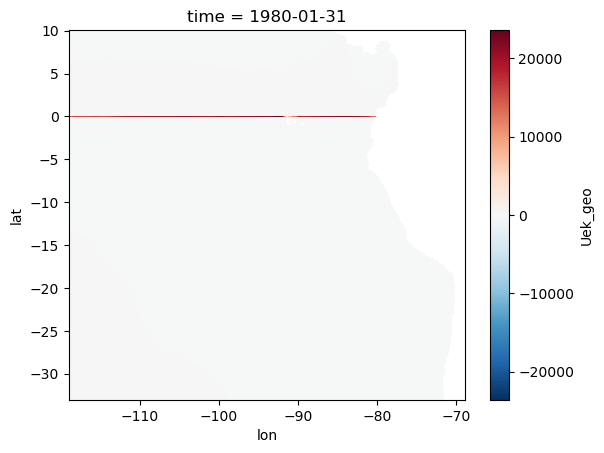

In [5]:
ds.Uek_geo.isel(time=0).plot()

In [6]:
## 111km mask or (1/12)*10*111 km
mask = coastal_band_mask(ds, var='Uek_geo', iterations=10)

wind_coastal = ds.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4)) 
wind_coastal

<xarray.Dataset> Size: 746MB
Dimensions:            (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon                (lon) float64 2kB -84.95 -84.87 -84.78 ... -68.95 -68.87
  * lat                (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.162 -4.079
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 107MB nan nan nan ... nan nan
    v10                (time, lat, lon) float64 107MB nan nan nan ... nan nan
    tau_alongshore     (time, lat, lon) float64 107MB nan nan nan ... nan nan
    Uekman_Crossshore  (time, lat, lon) float64 107MB nan nan nan ... nan nan
    Inshore_Uekman     (time, lat, lon) float64 107MB nan nan nan ... nan nan
    Uek_geo            (time, lat, lon) float64 107MB nan nan nan ... nan nan
    Vek_geo            (time, lat, lon) float64 107MB nan nan nan ... nan nan
    f                  (lat, lon) float64 247kB nan nan nan nan ... nan nan nan

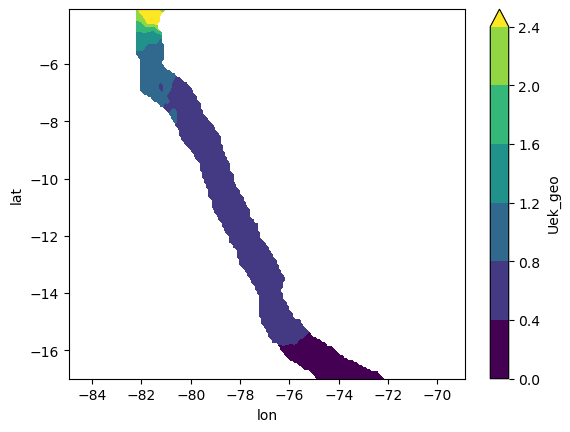

In [7]:
wind_coastal.Uek_geo.std('time').plot.contourf(robust=True)

### Now the $Ek_{int}$

In [8]:
def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,   # e.g. -5, -4  (south < north)
                  lon_west=-83, lon_east=-70,
                  delta_y=9250, delta_x=9250, N=12): #delta_y and delta_x are the resolution of the grid in meters
    """
    Compute Qdiv for a given lat band [lat_south, lat_north]
    using your current method.
    """

    # slice: note lat_south < lat_north
    Uek_ = (Uek).sel(
        lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east)
    )
    Vek_ = (Vek).sel(
        lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east)
    )

    # Boolean mask of valid ocean cells
    valid = xr.where(np.isfinite(Uek_), 1, 0)

    valid_e = valid.shift(lon=-1)  # east neighbour
    valid_w = valid.shift(lon=+1)  # west neighbour

    west_mask = (valid == 1) & (valid_w == 0)
    east_mask = (valid == 1) & (valid_e == 0)

    easternmost = Uek_.where(east_mask)   # inshore
    westernmost = Uek_.where(west_mask)   # offshore

    southernmost = Vek_.min(dim='lat', skipna=True)
    northernmost = Vek_.max(dim='lat', skipna=True)

    # QE, QW, QN, QS exactly as you wrote
    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * delta_y) ## as this value points to the coastal boundary it should be 0

    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * delta_y) ## points to the left

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * delta_x)

    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * delta_x) #points south
    
    # Qdiv = (QW + QS + QN) / (delta_x * (N - 1))
    Qdiv = (QW  + QN) / (delta_x * (N - 1)) #as the repeating cell
    # Qdiv = (QE + QW + QS + QN) / (delta_x * (N - 1))
    # Qdiv_Sv = (QE + QW + QS + QN) /10e6

    return Qdiv


In [9]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

results = []
lat_band_centers = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    Qdiv_band = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        lon_west=-83, lon_east=-70,
        delta_y=9250, delta_x=9250, N=12
    )

    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    
Qdiv_all = xr.concat(results, dim='lat_band')

U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

100%|████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 35.46it/s]


In [10]:
U_ek

<xarray.DataArray (lat_band: 12, time: 432)> Size: 41kB
array([[3.10763842, 1.99890872, 1.8394705 , ..., 6.26467287, 6.38076419,
        5.50675389],
       [3.50137843, 2.61040092, 2.76673167, ..., 6.44708477, 6.46943454,
        5.73893086],
       [3.44898457, 2.88329252, 3.6608334 , ..., 5.90457112, 5.87811848,
        5.53460565],
       ...,
       [3.8571607 , 3.50240244, 3.24993351, ..., 5.73252099, 5.70189712,
        4.94509665],
       [4.65010217, 4.29936125, 3.8548728 , ..., 6.62348282, 6.59488433,
        5.63248383],
       [4.58747456, 4.5523891 , 4.24120322, ..., 6.66801571, 6.60546613,
        5.68315023]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5

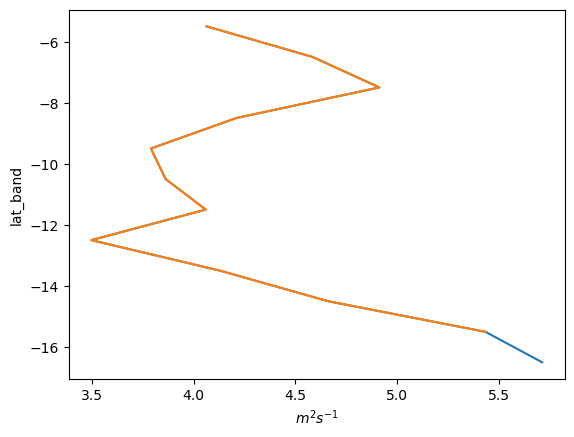

In [11]:
(U_ek).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
U_ek.sel(lat_band=slice(-5,-16)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')

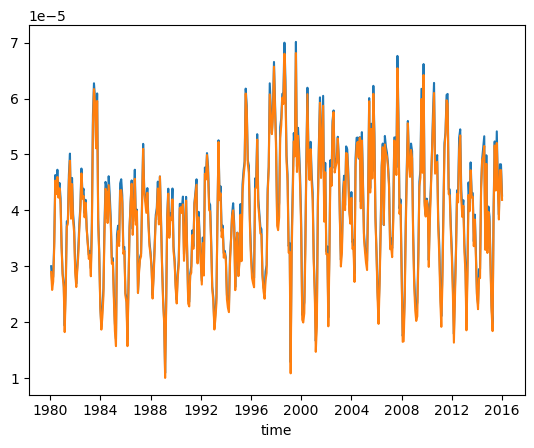

In [12]:
# d = (10/12)*111*1000
d = 111*1000
(U_ek.mean(dim='lat_band')/d).plot()
((U_ek.sel(lat_band=slice(-5,-16))).mean(dim='lat_band')/d).plot()

In [14]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()

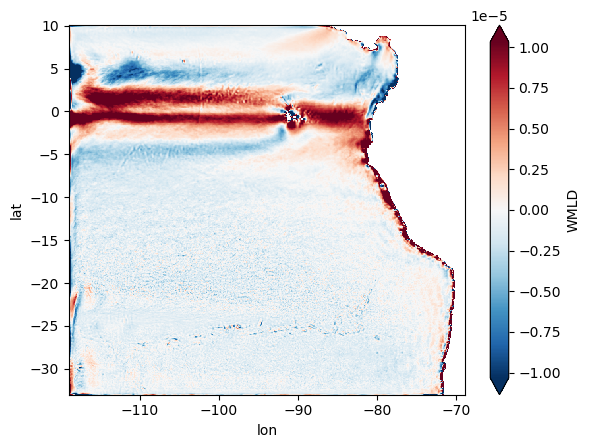

In [19]:
wmld.mean('time').WMLD.plot(robust=True)

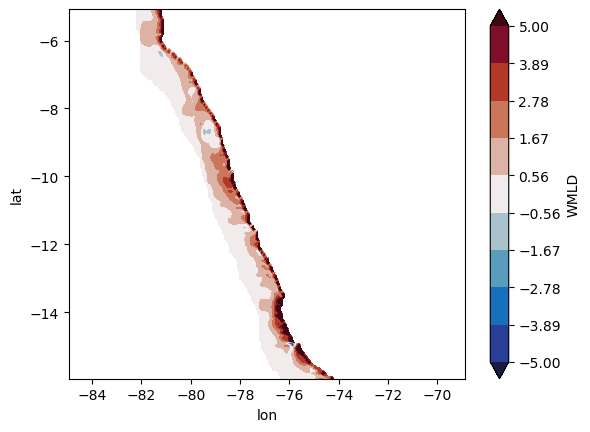

In [38]:
mask_ = coastal_band_mask(wmld,'WMLD',10)
(wmld*60*60*24).where(mask_).sel(lon=slice(-85,None),lat=slice(-16,-5)).mean('time').WMLD.plot.contourf(robust=True,vmax=5,vmin=-5,levels=10,cmap=cm.balance)

In [13]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

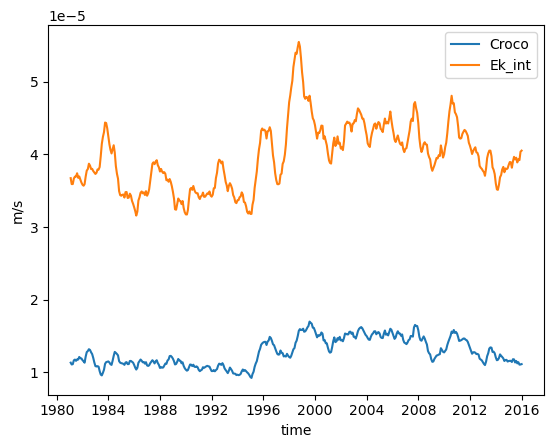

In [14]:
import matplotlib.pyplot as plt

wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco')
(((U_ek)).mean(dim='lat_band')/d).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
plt.legend()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [15]:
ssh = xr.open_dataset('SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

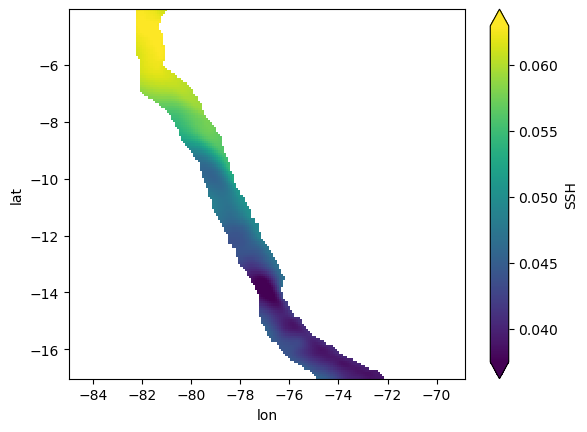

In [16]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
ssh.std('time').SSH.plot(robust=True)

In [17]:
results_ssh = []
lat_band_centers = []

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    Qdiv = qdiv_for_band(
        ssh.SSH, ssh.SSH,
        lat_south=lat_south, lat_north=lat_north,
        lon_west=-83, lon_east=-70,
        delta_y=9250, delta_x=9250, N=12
    )
    results_ssh.append(Qdiv)
    lat_band_centers.append(0.5 * (lat_south + lat_north))

ssh_qdiv = xr.concat(results_ssh, dim='lat_band')
ssh_qdiv = ssh_qdiv.assign_coords(lat_band=lat_band_centers)


100%|████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 48.46it/s]


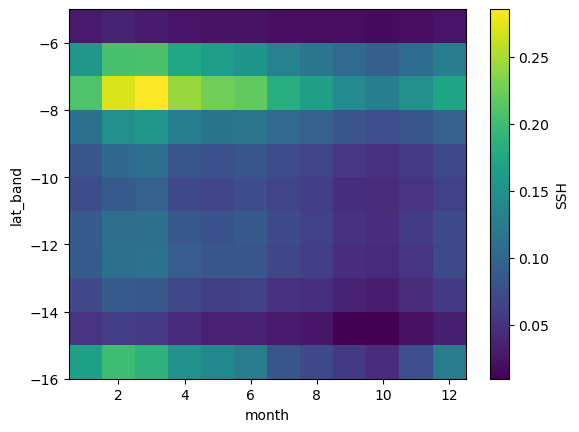

In [18]:
seasonality(ssh_qdiv).plot()

In [19]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

delta_f = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    f_band = wind_coastal.f.sel(lat=slice(lat_south, lat_north))

    southernmost = f_band.min(dim='lat', skipna=True)
    northernmost = f_band.max(dim='lat', skipna=True)
    
    delta_f.append((northernmost+southernmost)/2)

f_ = xr.concat(delta_f, dim='lat_band')
f_ = f_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)

100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 1511.37it/s]


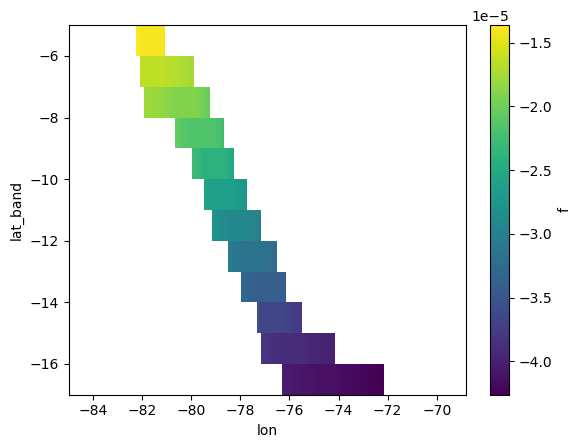

In [20]:
f_.plot()

In [21]:
# d_coast = 111*1000#1 grado de latitud en m
d_coast = (1/12)*10*1000*111
g = 9.81

u_geo = (g/f_)*(ssh_qdiv/d_coast)

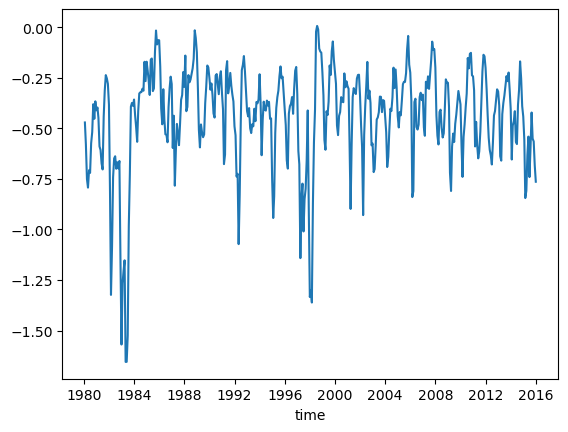

In [22]:
u_geo.mean(dim=('lat_band','lon')).plot()

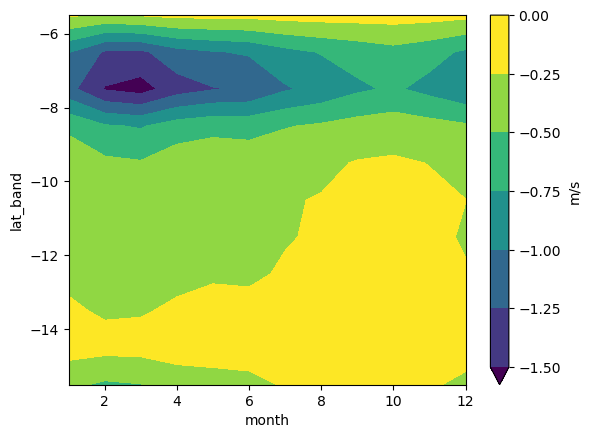

In [23]:
seasonality(u_geo.mean('lon').rename('m/s')).plot.contourf(robust=True)

### MLD

In [24]:
MLD_ds = xr.open_dataset('MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [25]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', iterations=3)
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-17,-4))
MLD_ds

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

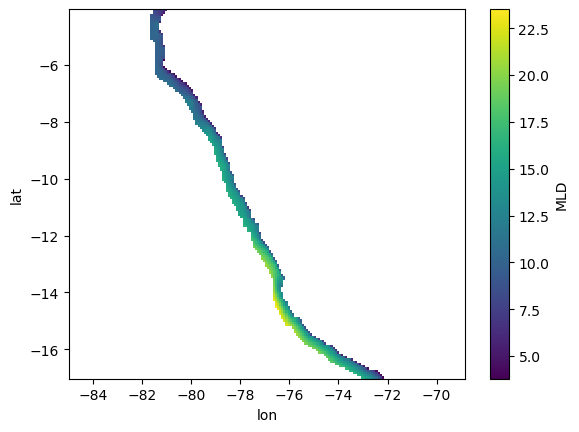

In [26]:
MLD_ds.MLD.std('time').plot()

In [27]:
lat_top_start = -5   # first northern edge
lat_top_end   = -16  # last northern edge

delta_mld = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    mld_band = MLD_ds.MLD.sel(lat=slice(lat_south, lat_north))

    southernmost = mld_band.min(dim='lat', skipna=True)
    northernmost = mld_band.max(dim='lat', skipna=True)
    
    delta_mld.append(northernmost-southernmost)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 276.69it/s]


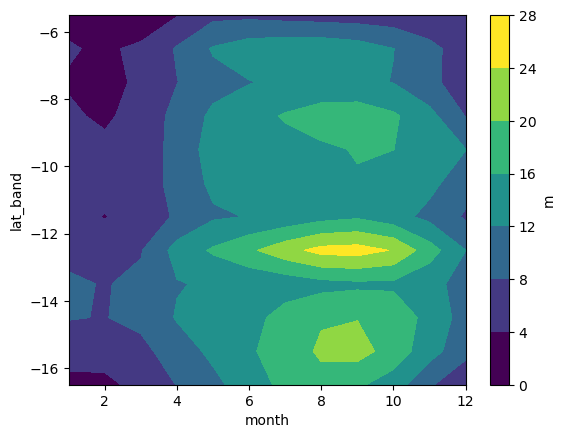

In [28]:
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

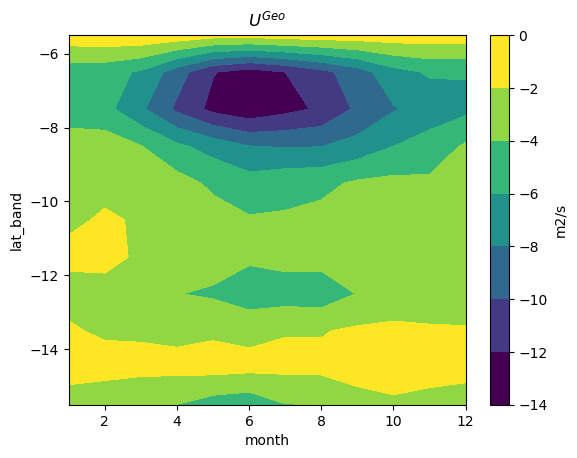

In [29]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)
plt.title('$U^{Geo}$')

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

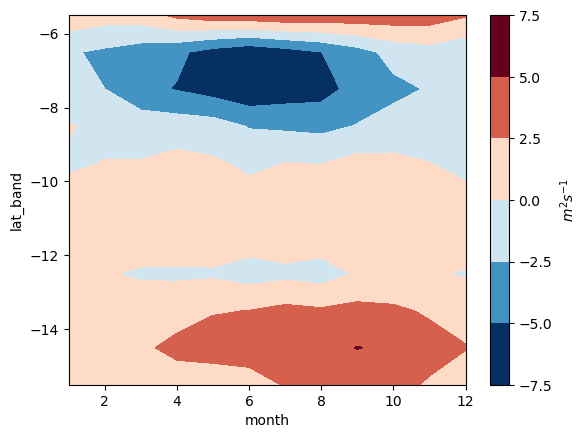

In [30]:
CUTI = U_ek + (U_geo)#m2/s

seasonality(CUTI.mean(dim='lon')).rename('$m^2s^{-1}$').plot.contourf(robust=True)

In [31]:
d = (1/12)*10*1000*111

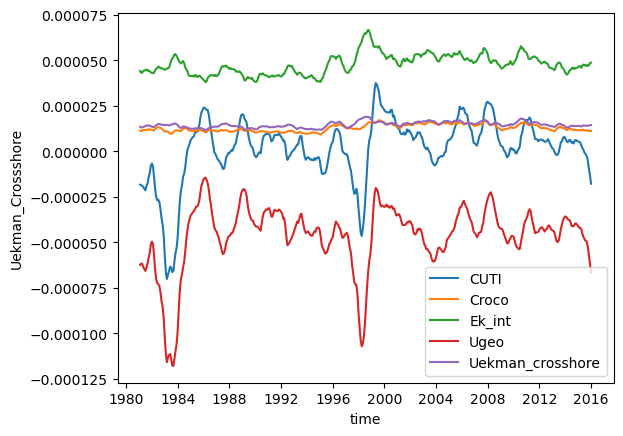

In [32]:
(CUTI/d).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco')
(((U_ek)).mean(dim='lat_band')/d).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
(U_geo/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')
(ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='Uekman_crosshore')

plt.legend()

In [33]:
# ds.Uekman_Crossshore